<a href="https://colab.research.google.com/github/RealGoldenGeneral/SmartVerify-Take-Home-Assignment/blob/main/notebooks/Modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Baseline Analysis
To analyze suspicious behaviour, we will calculate the mean, median, standard deviation, and interquartile range of intent_drift_score, unique_tables_accessed, entropy of table access sequence, session duration, and sensitive-table access count. We will also evaluate timing statistics between events along with intent drift and entropy thresholds. Finally we will describe the general activity among anomaly patterns.

In [1]:
# Load libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
# Import datasets
df_query = pd.read_csv("../data/new_query.csv")
df_session = pd.read_csv("../data/new_sessions.csv")
df_sequence = pd.read_csv("../data/sequences.csv")

In [3]:
# Create average row estimate feature
df_row_estimates = (
    df_query.groupby('session_id')['row_estimate'].mean().reset_index()
)
df_session = pd.merge(df_session, df_row_estimates, on='session_id', how='left')
df_session.head()

df_sequence["session_id"] = df_session["session_id"]
df_sequence["row_estimate"] = df_session["row_estimate"]
df_sequence.head()

,Unnamed: 0,start_time,end_time,enterprise_id,user_role,duration_seconds,num_events,declared_intent,is_anomalous_session,slow_drip_exfiltration,...,intent_drift_score,sensitive_table_access_count,select_count,update_count,join_count,aggregation_count,ddl_count,auth_count,session_id,row_estimate
0,0,2026-05-17 07:47:53,2026-05-17 08:25:43,ent_nexus_beta,1,2270,13,3,0,0,...,8.931782,0,9.0,1.0,1.0,2.0,0.0,0.0,sess_1000,1642.846154
1,1,2026-05-07 19:54:19,2026-05-07 20:22:05,ent_corp_alpha,0,1666,15,10,0,0,...,10.335002,0,8.0,2.0,3.0,2.0,0.0,0.0,sess_1001,3003.666667
2,2,2026-05-12 17:35:46,2026-05-12 17:59:21,ent_nexus_beta,1,1415,17,0,0,0,...,9.812710,0,14.0,0.0,2.0,1.0,0.0,0.0,sess_1002,2064.352941
3,3,2026-05-20 15:15:01,2026-05-20 16:01:57,ent_corp_alpha,4,2816,20,4,0,0,...,10.691161,0,15.0,2.0,0.0,3.0,0.0,0.0,sess_1003,3515.400000
4,4,2026-05-19 12:20:54,2026-05-19 12:53:01,ent_corp_alpha,0,1927,14,6,0,0,...,9.282293,0,7.0,3.0,2.0,2.0,0.0,0.0,sess_1004,1016.285714


## Summary Statistics

In [4]:
# Summary statistics
columns = ['intent_drift_score', 'unique_tables_accessed', 'entropy_table_access_sequence', 'duration_seconds', 'sensitive_table_access_count']
df_session.describe()[columns]

,intent_drift_score,unique_tables_accessed,entropy_table_access_sequence,duration_seconds,sensitive_table_access_count
count,230.000000,230.000000,230.000000,230.000000,230.000000
mean,11.212896,3.717391,1.680179,1768.508696,0.200000
std,3.953111,1.731585,0.506545,1652.860867,1.103389
min,7.704210,2.000000,0.713852,458.000000,0.000000
25%,9.423379,3.000000,1.444629,1089.750000,0.000000
50%,10.129631,3.000000,1.554585,1403.500000,0.000000
75%,11.688806,4.000000,1.885189,1769.500000,0.000000
max,47.271868,14.000000,3.597472,10111.000000,10.000000


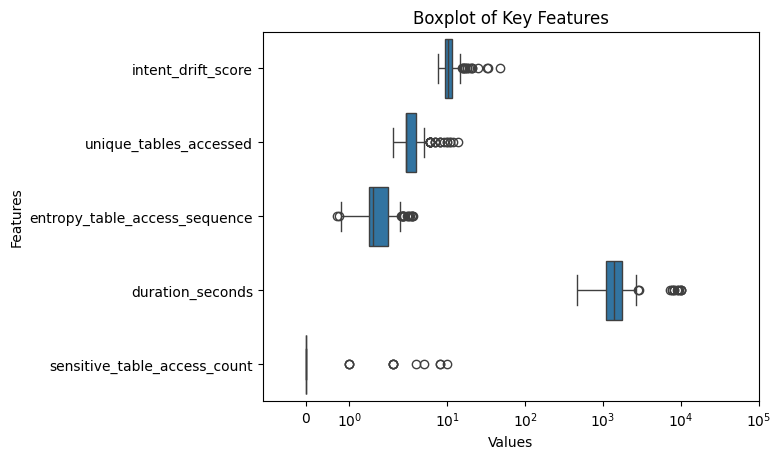

In [5]:
# Boxplot for key features
df_melted = df_session[columns].melt(var_name='Features', value_name='Values')
sns.boxplot(data=df_melted, x='Values', y='Features')
plt.title("Boxplot of Key Features")
plt.xlabel("Values")
plt.ylabel("Features")
plt.xscale('symlog')
plt.xlim(-1, 100000)
plt.show()

## Inter-event Timing Statistics

In [6]:
# Distribution of query events over time
df_query = df_query.sort_values(by='timestamp')
df_query['time_delta'].describe()

,time_delta
count,3309.000000
mean,112.251435
std,136.414222
min,0.000000
25%,24.000000
50%,71.000000
75%,151.000000
max,1709.000000


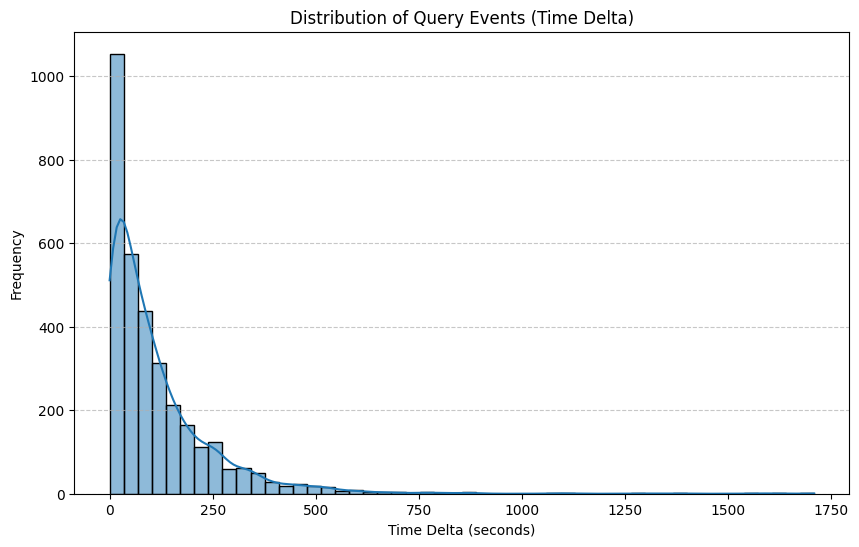

In [7]:
# Plot distribution of query events over time delta
plt.figure(figsize=(10, 6))
sns.histplot(data=df_query, x='time_delta', bins=50, kde=True)
plt.title("Distribution of Query Events (Time Delta)")
plt.xlabel("Time Delta (seconds)")
plt.ylabel("Frequency")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

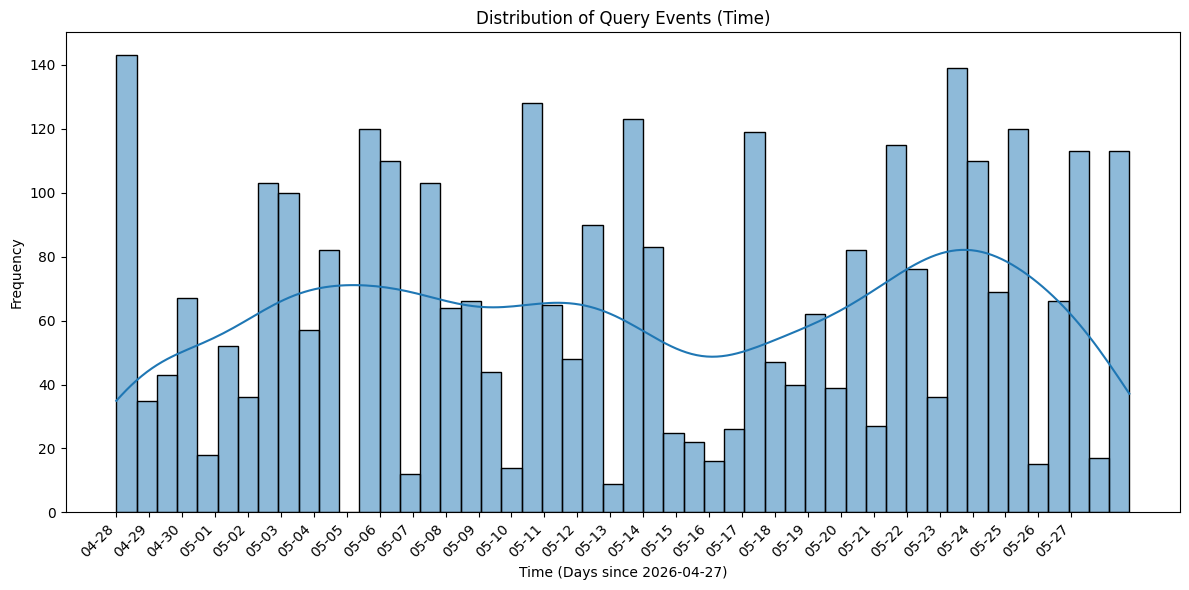

In [8]:
import matplotlib.dates as mdates

# Plot distirbution of query events over time
df_query['timestamp_dt'] = pd.to_datetime(df_query['timestamp'])
timestamp_unix_seconds = df_query['timestamp_dt'].astype(int) / 10**9

# Convert Unix seconds back to datetime objects for plotting
# We need a reference point. The minimum timestamp in the data will serve as a good base.
min_timestamp_dt = df_query['timestamp_dt'].min()
# Calculate the time in days relative to the minimum timestamp for better readability on the axis
time_since_min_days = (df_query['timestamp_dt'] - min_timestamp_dt).dt.total_seconds() / (60 * 60 * 24)

plt.figure(figsize=(12, 6))
sns.histplot(x=time_since_min_days, bins=50, kde=True)

# Get current axis
ax = plt.gca()

# Calculate actual dates for the ticks based on the min_timestamp_dt
# We'll create new tick locations and labels
start_date = min_timestamp_dt.date()
end_date = df_query['timestamp_dt'].max().date()

# Generate tick locations in 'days since start' for date intervals (e.g., every 5 days)
date_range = pd.date_range(start=start_date, end=end_date, freq='D')
tick_locations = [(d - min_timestamp_dt).days for d in date_range]
tick_labels = [d.strftime('%m-%d') for d in date_range]

# Filter out tick locations that are outside the plot's data range, if any
valid_tick_locations = [loc for loc in tick_locations if loc >= 0 and loc <= time_since_min_days.max()]
valid_tick_labels = [label for loc, label in zip(tick_locations, tick_labels) if loc >= 0 and loc <= time_since_min_days.max()]

ax.set_xticks(valid_tick_locations)
ax.set_xticklabels(valid_tick_labels, rotation=45, ha='right')

plt.title("Distribution of Query Events (Time)")
plt.xlabel(f"Time (Days since {min_timestamp_dt.strftime('%Y-%m-%d')})")
plt.ylabel("Frequency")
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

# Baselines

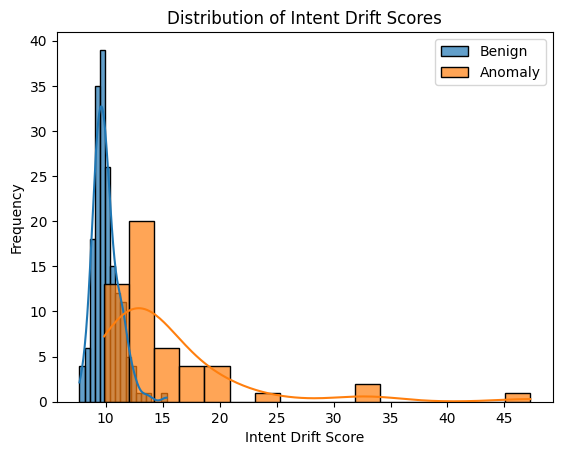

In [9]:
# Threshold analysis for intent drift
df_benign = df_session[df_session['is_anomalous_session'] == 0]['intent_drift_score']
df_anomaly = df_session[df_session['is_anomalous_session'] == 1]['intent_drift_score']

sns.histplot(data=df_benign, label='Benign', kde=True, alpha=0.7)
sns.histplot(data=df_anomaly, label='Anomaly', kde=True, alpha=0.7)
plt.title("Distribution of Intent Drift Scores")
plt.xlabel("Intent Drift Score")
plt.ylabel("Frequency")
plt.legend()
plt.show()

This visualization shows that the baseline of anomalous labels is around 12 intent drift score. This score is around the point where we can confidently say the activity is suspicious as there are more anomalies than benign sessions.

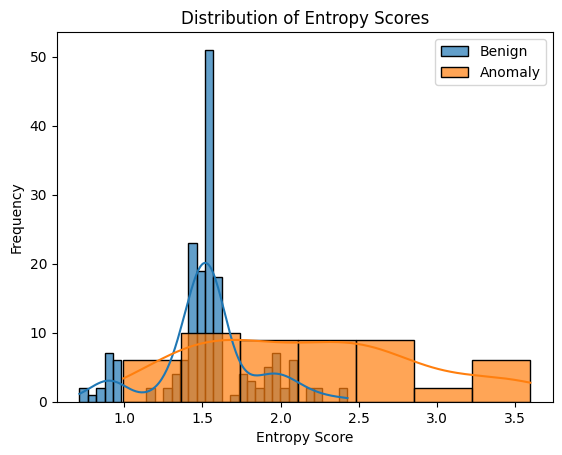

In [10]:
# Threshold analysis for entropy
df_benign = df_session[df_session['is_anomalous_session'] == 0]['entropy_table_access_sequence']
df_anomaly = df_session[df_session['is_anomalous_session'] == 1]['entropy_table_access_sequence']

sns.histplot(data=df_benign, label='Benign', kde=True, alpha=0.7)
sns.histplot(data=df_anomaly, label='Anomaly', kde=True, alpha=0.7)
plt.title("Distribution of Entropy Scores")
plt.xlabel("Entropy Score")
plt.ylabel("Frequency")
plt.legend()
plt.show()

The entropy baseline would be around 2.0 because the score would be the point where more sessions are anomalies than normal.

# Descriptive Analysis
Descriptive analysis across patterns to determine typical behaviour

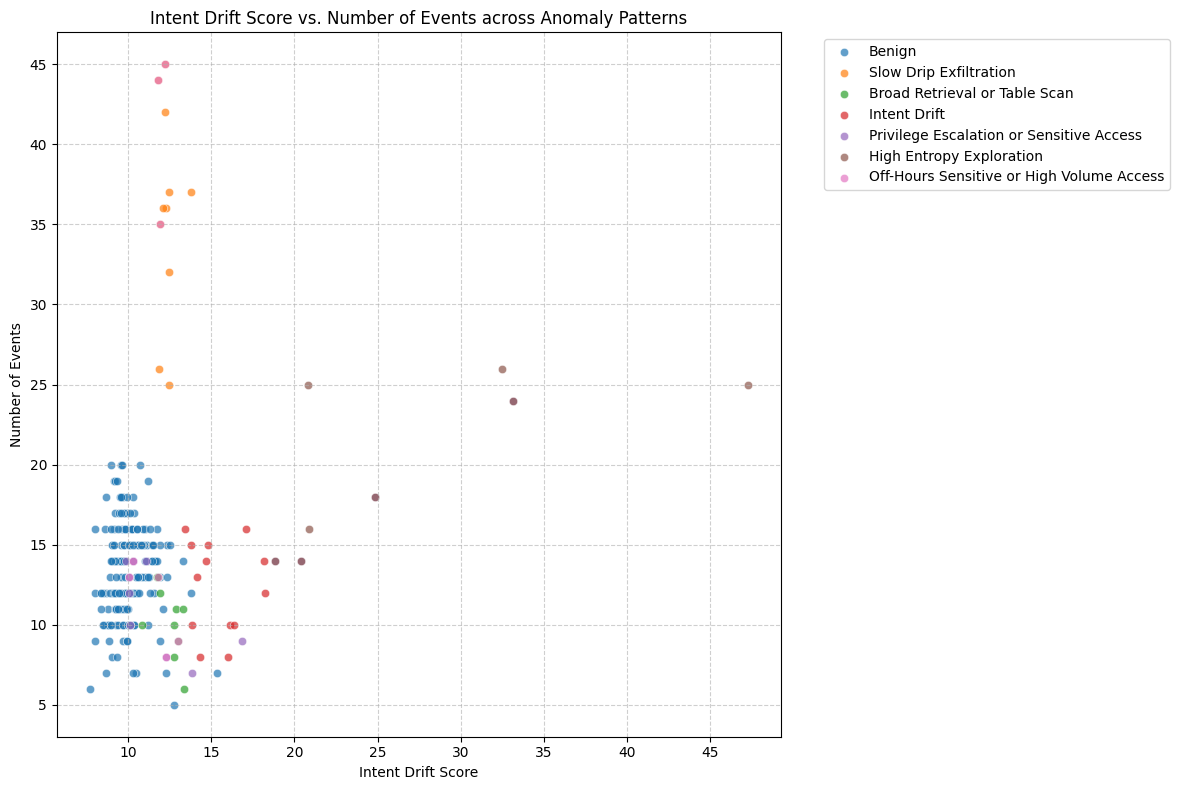

In [11]:
# Intent Drift Score and Number of Events across patterns of anomalies
df_benign_sessions = df_session[df_session['is_anomalous_session'] == 0]
df_sde_sessions = df_session[df_session['slow_drip_exfiltration'] == 1]
df_br_or_ts_sessions = df_session[df_session['broad_retrieval_or_table_scan'] == 1]
df_id_sessions = df_session[df_session['intent_drift'] == 1]
df_pe_or_sav_sessions = df_session[df_session['privilege_escalation_or_sensitive_access_violation'] == 1]
df_hee_sessions = df_session[df_session['high_entropy_exploration'] == 1]
df_ohs_or_hva_sessions = df_session[df_session['off_hours_sensitive_or_high_volume_access'] == 1]

plt.figure(figsize=(12, 8))
sns.scatterplot(data=df_benign_sessions, x='intent_drift_score', y='num_events', label='Benign', alpha=0.7)
sns.scatterplot(data=df_sde_sessions, x='intent_drift_score', y='num_events', label='Slow Drip Exfiltration', alpha=0.7)
sns.scatterplot(data=df_br_or_ts_sessions, x='intent_drift_score', y='num_events', label='Broad Retrieval or Table Scan', alpha=0.7)
sns.scatterplot(data=df_id_sessions, x='intent_drift_score', y='num_events', label='Intent Drift', alpha=0.7)
sns.scatterplot(data=df_pe_or_sav_sessions, x='intent_drift_score', y='num_events', label='Privilege Escalation or Sensitive Access', alpha=0.7)
sns.scatterplot(data=df_hee_sessions, x='intent_drift_score', y='num_events', label='High Entropy Exploration', alpha=0.7)
sns.scatterplot(data=df_ohs_or_hva_sessions, x='intent_drift_score', y='num_events', label='Off-Hours Sensitive or High Volume Access', alpha=0.7)

plt.title("Intent Drift Score vs. Number of Events across Anomaly Patterns")
plt.xlabel("Intent Drift Score")
plt.ylabel("Number of Events")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

This scatter plot clearly identifies slow drip exfiltrations, intent drift, privilege escalation or sensitive access, and high entropy exploration well as the clusters seperate themselves from each other as seen by the gaps between benign, intent drift, high entropy exploration and slow drip exfiltration. The scatterplot, however fails to seperate broad retrieval or table scan and off-hours sensitive or high volume access from each other, suggesting that they can be seperated through other means.

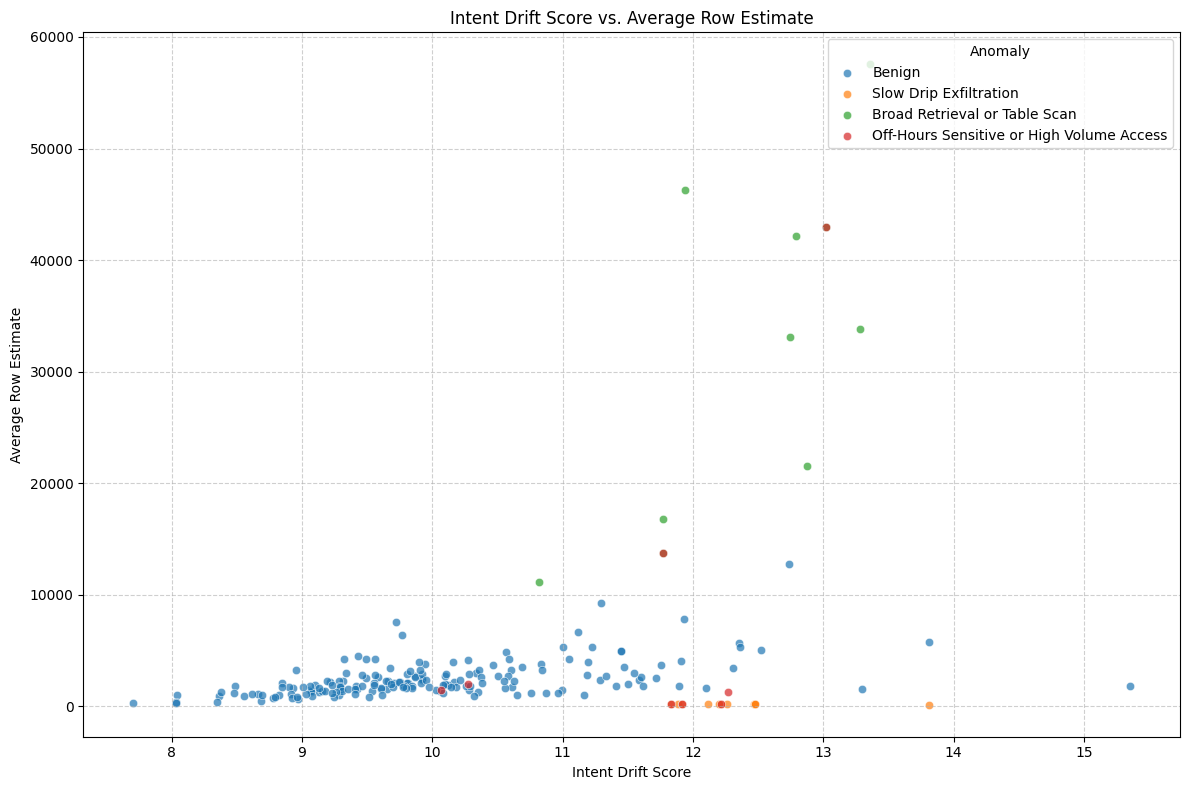

In [12]:
# Seperate BRTS and OHSHVA anomalies from other sessions
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df_benign_sessions, x='intent_drift_score', y='row_estimate', label='Benign', alpha=0.7)
sns.scatterplot(data=df_sde_sessions, x='intent_drift_score', y='row_estimate', label='Slow Drip Exfiltration', alpha=0.7)
sns.scatterplot(data=df_br_or_ts_sessions, x='intent_drift_score', y='row_estimate', label='Broad Retrieval or Table Scan', alpha=0.7)
sns.scatterplot(data=df_ohs_or_hva_sessions, x='intent_drift_score', y='row_estimate', label='Off-Hours Sensitive or High Volume Access', alpha=0.7)
plt.title("Intent Drift Score vs. Average Row Estimate")
plt.xlabel("Intent Drift Score")
plt.ylabel("Average Row Estimate")
plt.legend(title='Anomaly', loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

This visualization proves that the average row estimate could split off broad retrieval or table scan anomalies from benign and slow drip exfiltration. Because of the varying nature of off-hours sensitive or high volume access anomalies, separating them from other sessions will be the hardest to seperate from other types.

# Baseline Model
For our baseline model, we have elected to use support vector machines. This is because SVMs can perform consistently well with training and is memory efficent. SVMs provide classification boundaries and clear visualizations of clusters of information. SVMs are more memory efficent than Long Short Term Memory (LSTM) models and are not vulnerable to the exploding gradient problem, but have more expensive cross validation when compared to LSTMs.

Our assumptions with SVMs are that both user_role and declared_intent are integral to the classification of a session.

Our SVM pipeline is as follows: Our input is first scaled and dimension reduced to 2 dimensions. This is to equalize all data and plot out decision boundaries. PCA also reduces overfitting. We then use Grid Search Cross Validation to pick the best kernel. Finally we train and test the SVM using a 70/15/15 train/val/test split.

In [13]:
# Load libraries for machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

In [14]:
# Preprocessing
df_session['declared_intent'] = pd.Categorical(df_session['declared_intent']).codes
df_session['user_role'] = pd.Categorical(df_session['user_role']).codes
df_session['enterprise_id'] = pd.Categorical(df_session['enterprise_id']).codes

columns = ['intent_drift_score', 'unique_tables_accessed', 'entropy_table_access_sequence', 'duration_seconds', 'sensitive_table_access_count', 'row_estimate', 'num_events', 'cross_table_join_count', 'time_delta_mean', 'confidence_mean', 'user_role', 'declared_intent','select_count', 'update_count', 'join_count', 'aggregation_count', 'ddl_count', 'auth_count', 'enterprise_id']
X = df_session[columns]
y = df_session['is_anomalous_session']

def preprocess_data(X, y):
  scaler = StandardScaler()
  # fit_transform returns a numpy array; convert it back to a DataFrame to use pandas methods or use train_test_split
  X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)

  # Using train_test_split is generally cleaner for multi-step splits
  X_train, X_temp, y_train, y_temp = train_test_split(X_scaled, y, test_size=0.3, random_state=42)
  X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

  return X_train, X_val, X_test, y_train, y_val, y_test

X_train, X_val, X_test, y_train, y_val, y_test = preprocess_data(X, y)

In [15]:
import numpy as np
from sklearn.decomposition import PCA

# Re-run preprocessing to ensure X_train, X_val, X_test are 19-dimensional scaled data
# Use dummy variables for y outputs as they are not needed for PCA input here, but X,y are globals.
X_train_full_features, X_val_full_features, X_test_full_features, _, _, _ = preprocess_data(X, y)

def dimension_reduction(X_train_data, X_val_data, X_test_data):
  pca = PCA(n_components=2)
  # Fit PCA on the 19-dimensional training data
  X_train_pca = pca.fit_transform(X_train_data)
  X_val_pca = pca.transform(X_val_data)
  X_test_pca = pca.transform(X_test_data)
  # Return the pca object along with the transformed data
  return X_train_pca, X_val_pca, X_test_pca, pca

# Update the assignment to capture the returned pca object, and assign the PCA-transformed data
# to the global X_train, X_val, X_test variables for subsequent SVM steps.
X_train_pca, X_val_pca, X_test_pca, pca_transformer = dimension_reduction(X_train_full_features, X_val_full_features, X_test_full_features)

X_train = X_train_pca
X_val = X_val_pca
X_test = X_test_pca

print("PCA fitted on 19-dimensional data.")
print(f"Shape of pca_transformer.components_: {pca_transformer.components_.shape}")
print(f"Shape of pca_transformer.mean_: {pca_transformer.mean_.shape}")

PCA fitted on 19-dimensional data.
Shape of pca_transformer.components_: (2, 19)
Shape of pca_transformer.mean_: (19,)


In [16]:
# Cross validation
from sklearn.model_selection import GridSearchCV
def cross_validate(X_train, y_train):
  svm_classifier = SVC(random_state=42, class_weight="balanced")
  param_grid = {'kernel': ['linear', 'rbf'], 'C': [0.1, 1, 10]}
  grid_search = GridSearchCV(svm_classifier, param_grid, cv=5)
  grid_search.fit(X_train, y_train)
  return grid_search.best_estimator_

svc = cross_validate(X_train, y_train)

In [17]:
# Training SVM
def train_svm(X_train, y_train):
  svc.fit(X_train, y_train)

svm_classifier = train_svm(X_train, y_train)
# Test SVM
def test_svm(svm_classifier, X_test, y_test):
  y_pred = svm_classifier.predict(X_test)
  print("Confusion Matrix:")
  print(confusion_matrix(y_test, y_pred))
  print("\nClassification Report:")
  print(classification_report(y_test, y_pred))

test_svm(svc, X_test, y_test)

Confusion Matrix:
[[28  0]
 [ 4  3]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      1.00      0.93        28
           1       1.00      0.43      0.60         7

    accuracy                           0.89        35
   macro avg       0.94      0.71      0.77        35
weighted avg       0.90      0.89      0.87        35



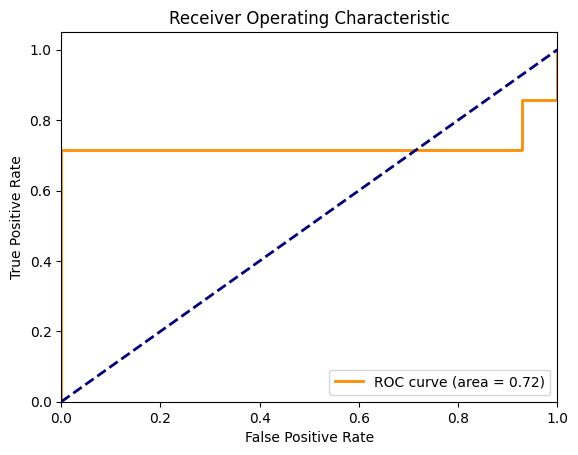

In [18]:
# Visualize ROC curve
from sklearn.metrics import roc_curve, auc
def visualize_roc_curve(svm_classifier, X, y):
  y_pred_prob = svm_classifier.decision_function(X)
  fpr, tpr, thresholds = roc_curve(y, y_pred_prob)
  roc_auc = auc(fpr, tpr)
  plt.figure()
  plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
  plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
  plt.xlim([0.0, 1.0])
  plt.ylim([0.0, 1.05])
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.title('Receiver Operating Characteristic')
  plt.legend(loc="lower right")
  plt.show()
  return fpr, tpr, thresholds

fpr, tpr, thresholds = visualize_roc_curve(svc, X_test, y_test)

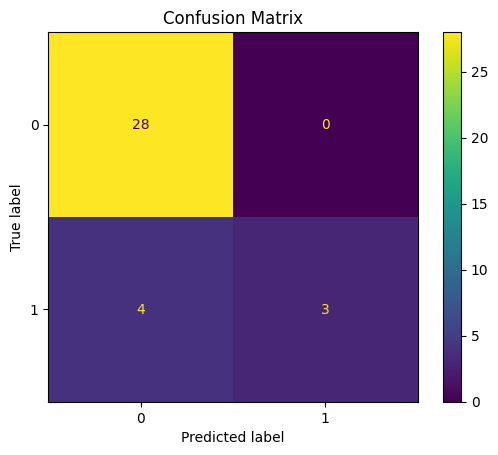

In [19]:
# Visualize confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay
def visualize_confusion_matrix(svm_classifier, X_test, y_test):
  cm = confusion_matrix(y_test, svm_classifier.predict(X_test))
  disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y_test))
  disp.plot()
  plt.title("Confusion Matrix")
  plt.show()

visualize_confusion_matrix(svc, X_test, y_test)

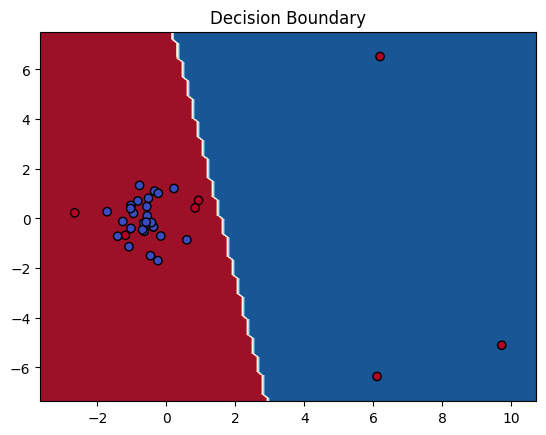

In [20]:
# Plot decision boundary
from sklearn.inspection import DecisionBoundaryDisplay
def plot_decision_boundary(svm_classifier, X, y):
  DecisionBoundaryDisplay.from_estimator(
      svm_classifier,
      X,
      response_method="predict",
      cmap='RdBu'
  )
  plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors="k", cmap='coolwarm')
  plt.title("Decision Boundary")
  plt.show()

plot_decision_boundary(svc, X_test, y_test)

In [21]:
# Per-enterprise performance breakdown
def enterprise_performance_breakdown(svm_classifier, X_test, y_test, full_df_session):
  # Get the original session data corresponding to the test set indices
  # y_test's index contains the original row labels from full_df_session for the test set.
  df_test_subset = full_df_session.loc[y_test.index].copy()

  # Make predictions on the PCA-transformed test set
  y_pred = svm_classifier.predict(X_test)

  # Assign predictions to the test subset DataFrame
  df_test_subset['predicted_label'] = y_pred

  # Also ensure the true labels are in this subset for comparison
  df_test_subset['is_anomalous_session'] = y_test.values

  # Convert labels to descriptive categories
  df_test_subset['predicted_label'] = df_test_subset['predicted_label'].astype(str)
  df_test_subset['predicted_label'] = pd.Categorical(df_test_subset['predicted_label']).rename_categories(['Normal', 'Anomaly'])

  df_test_subset['is_anomalous_session'] = df_test_subset['is_anomalous_session'].astype(str)
  df_test_subset['is_anomalous_session'] = pd.Categorical(df_test_subset['is_anomalous_session']).rename_categories(['Normal', 'Anomaly'])

  # Convert enterprise_id codes to strings for plotting, and then to categorical
  df_test_subset['enterprise_id'] = df_test_subset['enterprise_id'].astype(str)
  df_test_subset['enterprise_id'] = pd.Categorical(df_test_subset['enterprise_id'])
  # Re-categorize using its own unique values to ensure all present categories are recognized
  df_test_subset['enterprise_id'] = df_test_subset['enterprise_id'].cat.rename_categories(df_test_subset['enterprise_id'].unique())


  # Group by enterprise_id, predicted_label, and actual is_anomalous_session
  df_enterprise_performance = df_test_subset.groupby(['enterprise_id', 'predicted_label', 'is_anomalous_session'], observed=True).size().reset_index(name='count')
  return df_enterprise_performance

# Call the function with the original full df_session, X_test (PCA-transformed), and y_test (true labels for test set)
df_enterprise_performance = enterprise_performance_breakdown(svc, X_test, y_test, df_session)

# Plot per-enterprise performance
df_enterprise_performance = df_enterprise_performance.sort_values(by='enterprise_id')
fig = px.bar(df_enterprise_performance, x='enterprise_id', y='count', color='is_anomalous_session', barmode='group', title='Enterprise Performance Breakdown')
fig.update_layout(xaxis_title='Enterprise ID', yaxis_title='Count')
fig.update_xaxes(type='category', categoryorder='array', categoryarray=df_enterprise_performance['enterprise_id'].unique())
fig.show()

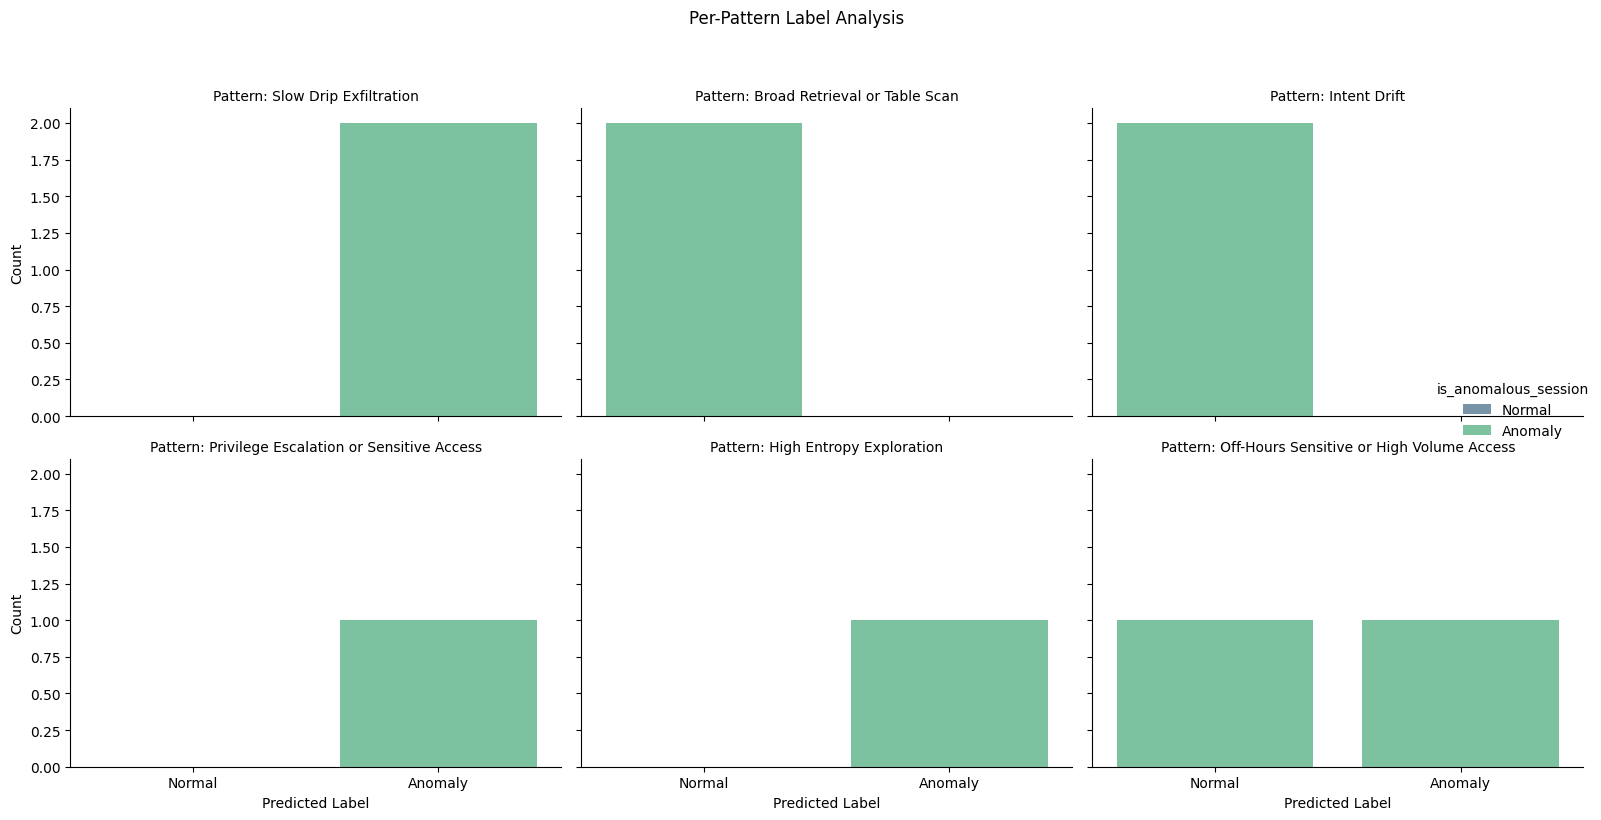

In [22]:
labels = ['slow_drip_exfiltration', 'broad_retrieval_or_table_scan', 'intent_drift', 'privilege_escalation_or_sensitive_access_violation', 'high_entropy_exploration', 'off_hours_sensitive_or_high_volume_access']
def per_pattern_label_analysis(svm_classifier, X_test, y_test, labels):
  df_labels_list = []
  df_test_subset = df_session.loc[y_test.index].copy()
  y_pred = svm_classifier.predict(X_test)
  df_test_subset['predicted_label'] = y_pred
  df_test_subset['is_anomalous_session'] = y_test
  df_test_subset['predicted_label'] = df_test_subset['predicted_label'].astype(str)
  df_test_subset['predicted_label'] = pd.Categorical(df_test_subset['predicted_label']).rename_categories(['Normal', 'Anomaly'])
  df_test_subset['is_anomalous_session'] = df_test_subset['is_anomalous_session'].astype(str)
  df_test_subset['is_anomalous_session'] = pd.Categorical(df_test_subset['is_anomalous_session']).rename_categories(['Normal', 'Anomaly'])
  for label in labels:
    df_label = df_test_subset[df_test_subset[label] == 1].copy() # Ensure a copy to avoid SettingWithCopyWarning
    df_label['Pattern'] = label # Add a new column to identify the pattern
    df_labels_list.append(df_label)
  return pd.concat(df_labels_list)

combined_df_labels = per_pattern_label_analysis(svc, X_test, y_test, labels)

# Map pattern labels to more readable names for the plot
pattern_names = {
    'slow_drip_exfiltration': 'Slow Drip Exfiltration',
    'broad_retrieval_or_table_scan': 'Broad Retrieval or Table Scan',
    'intent_drift': 'Intent Drift',
    'privilege_escalation_or_sensitive_access_violation': 'Privilege Escalation or Sensitive Access',
    'high_entropy_exploration': 'High Entropy Exploration',
    'off_hours_sensitive_or_high_volume_access': 'Off-Hours Sensitive or High Volume Access'
}
combined_df_labels['Pattern'] = combined_df_labels['Pattern'].map(pattern_names)

# Create the faceted plot
g = sns.catplot(
    data=combined_df_labels,
    x='predicted_label',
    hue='is_anomalous_session',
    col='Pattern',
    kind='count',
    col_wrap=3, # Display 3 plots per row
    height=4, aspect=1.2, # Adjust height and aspect ratio
    alpha=0.7,
    palette='viridis' # Choose a color palette
)

g.set_axis_labels("Predicted Label", "Count")
g.set_titles("Pattern: {col_name}")
plt.suptitle("Per-Pattern Label Analysis", y=1.02) # Adjust overall title position
plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout to prevent title overlap
plt.show()

# Sequential Modeling
We use LSTM models with sequential coding. We decided to use LSTM because the model is built for predicting sequentially naturally. The recurrency of the network results in the network remembering thousands of steps. This fits our timestamped dataset as the sessions are sequenced.

For this model, we assume that declared_intent and user_role are a part of the analysis for any anomalous action from any AI agent. We also assume that the specific time and date of the session are also a part of the analysis of the model.

The LSTM network infrastructure follows as such: We input our features in batches of 32 to the LSTM layer first to learn sequences. Then our batches go through a dropout and batch normalization layer to prevent overfitting. The next layer is the ReLU layer meant to process gradients. After another batch normalization and dropout layer, we get our classification through a sigmoid layer.

In [23]:
# Load LSTM libraries
from keras.models import Sequential
from keras.layers import LSTM, Dense, BatchNormalization, Dropout
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping, LearningRateScheduler

In [24]:
# Preprocessing sequences

def preprocess_data_lstm(df_sequence):
  df_sequence['start_time'] = pd.to_datetime(df_sequence['start_time'])
  df_sequence['end_time'] = pd.to_datetime(df_sequence['end_time'])
  df_sequence['duration_seconds'] = (df_sequence['end_time'] - df_sequence['start_time']).dt.total_seconds()
  df_sequence['session_id'] = df_sequence['session_id'].astype(str)

  if 'declared_intent' in df_sequence.columns and df_sequence['declared_intent'].dtype == 'object':
    df_sequence['declared_intent'] = pd.Categorical(df_sequence['declared_intent']).codes
  if 'user_role' in df_sequence.columns and df_sequence['user_role'].dtype == 'object':
    df_sequence['user_role'] = pd.Categorical(df_sequence['user_role']).codes
  return df_sequence

df_sequence = preprocess_data_lstm(df_sequence)

In [25]:
# Train-val-test split
def train_val_test_split(df_sequence):
  df_sequence = df_sequence.sort_values(by='start_time')
  train_size = int(0.7 * len(df_sequence))
  val_size = int(0.15 * len(df_sequence))
  train_data = df_sequence[:train_size]
  val_data = df_sequence[train_size:train_size+val_size]
  test_data = df_sequence[train_size+val_size:]
  return train_data, val_data, test_data

train_data, val_data, test_data = train_val_test_split(df_sequence)

In [26]:
# Extract features and targets
lstm_feature_cols = ['intent_drift_score', 'unique_tables_accessed', 'entropy_table_access_sequence', 'duration_seconds', 'sensitive_table_access_count', 'row_estimate']
lstm_target_col = 'is_anomalous_session'

def extract_features_targets(train_data, val_data, test_data):
  X_train_lstm = train_data[lstm_feature_cols]
  y_train_lstm = train_data[lstm_target_col]

  X_val_lstm = val_data[lstm_feature_cols]
  y_val_lstm = val_data[lstm_target_col]

  X_test_lstm = test_data[lstm_feature_cols]
  y_test_lstm = test_data[lstm_target_col]
  return X_train_lstm, y_train_lstm, X_val_lstm, y_val_lstm, X_test_lstm, y_test_lstm

X_train_lstm, y_train_lstm, X_val_lstm, y_val_lstm, X_test_lstm, y_test_lstm = extract_features_targets(train_data, val_data, test_data)

In [27]:
# Scale data
def scale_data(X_train_lstm, X_val_lstm, X_test_lstm):
  scaler = StandardScaler()
  X_train_lstm_scaled = scaler.fit_transform(X_train_lstm)
  X_val_lstm_scaled = scaler.transform(X_val_lstm)
  X_test_lstm_scaled = scaler.transform(X_test_lstm)
  return X_train_lstm_scaled, X_val_lstm_scaled, X_test_lstm_scaled

X_train_lstm_scaled, X_val_lstm_scaled, X_test_lstm_scaled = scale_data(X_train_lstm, X_val_lstm, X_test_lstm)

In [28]:
# Reshape for LSTM input
def reshape_lstm_input(X_train_lstm_scaled, X_val_lstm_scaled, X_test_lstm_scaled):
  n_features = len(lstm_feature_cols)
  X_train_lstm_reshaped = X_train_lstm_scaled.reshape(X_train_lstm_scaled.shape[0], n_features, 1)
  X_val_lstm_reshaped = X_val_lstm_scaled.reshape(X_val_lstm_scaled.shape[0], n_features, 1)
  X_test_lstm_reshaped = X_test_lstm_scaled.reshape(X_test_lstm_scaled.shape[0], n_features, 1)
  return X_train_lstm_reshaped, X_val_lstm_reshaped, X_test_lstm_reshaped

X_train_lstm_reshaped, X_val_lstm_reshaped, X_test_lstm_reshaped = reshape_lstm_input(X_train_lstm_scaled, X_val_lstm_scaled, X_test_lstm_scaled)

In [29]:
from sklearn.utils.class_weight import compute_class_weight

# Calculate class weights based on the original (imbalanced) training data
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_lstm),
    y=y_train_lstm
)
class_weight_dict = {i: class_weights[i] for i in range(len(class_weights))}

# LSTM Classifier
def lstm_classifier(X_train_lstm_reshaped, y_train_lstm_resampled, class_weight_dict):
  model = Sequential()
  model.add(LSTM(64, input_shape=(X_train_lstm_reshaped.shape[1], 1)))
  model.add(BatchNormalization())
  model.add(Dropout(0.5))
  model.add(Dense(32, activation='relu'))
  model.add(BatchNormalization())
  model.add(Dropout(0.5))
  model.add(Dense(1, activation='sigmoid'))
  model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=0.0001), metrics=['accuracy'])
  early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
  model.fit(X_train_lstm_reshaped, y_train_lstm_resampled, epochs=100, batch_size=32, validation_data=(X_val_lstm_reshaped, y_val_lstm), callbacks=[early_stopping], class_weight=class_weight_dict)
  return model

model = lstm_classifier(X_train_lstm_reshaped, y_train_lstm, class_weight_dict)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 9s 212ms/step - accuracy: 0.3354 - loss: 1.7074 - val_accuracy: 0.2353 - val_loss: 0.7051
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.4410 - loss: 1.4759 - val_accuracy: 0.2647 - val_loss: 0.7023
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.4658 - loss: 1.1549 - val_accuracy: 0.3529 - val_loss: 0.6992
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.4658 - loss: 1.0514 - val_accuracy: 0.4412 - val_loss: 0.6967
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.5280 - loss: 0.9881 - val_accuracy: 0.7941 - val_loss: 0.6938
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.5155 - loss: 1.2914 - val_accuracy: 0.8529 - val_loss: 0.6898
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.5342 - loss: 1.0598 - val_accuracy: 0.8529 - val_loss: 0.6858
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.4596 - loss: 1.1464 - val_accuracy: 0.8529 - val_loss

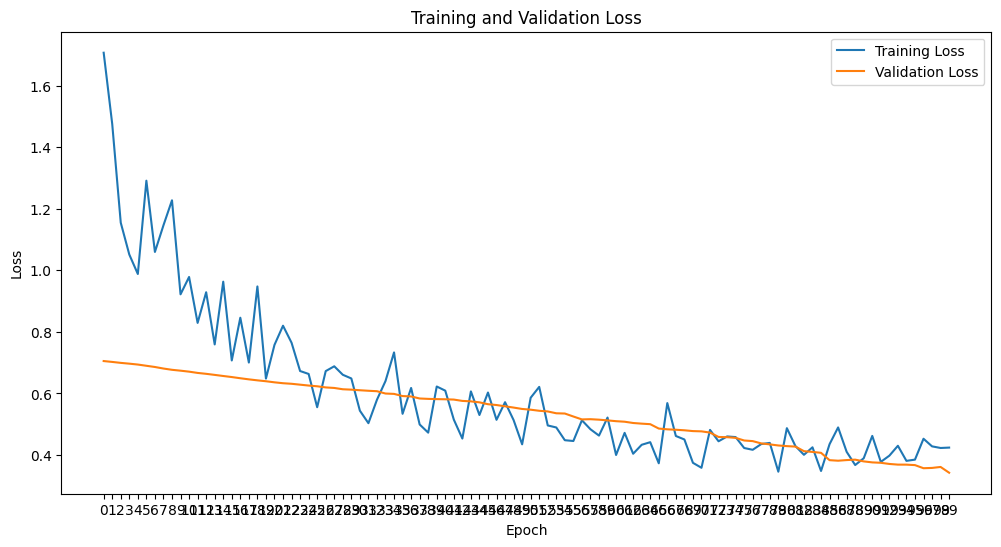

In [30]:
# Visualize LSTM Training
def visualize_lstm_training(model):
  plt.figure(figsize=(12, 6))
  plt.plot(model.history.history['loss'], label='Training Loss')
  plt.plot(model.history.history['val_loss'], label='Validation Loss')
  plt.xlabel('Epoch')
  plt.xticks(range(0, len(model.history.history['loss'])))
  plt.ylabel('Loss')
  plt.title('Training and Validation Loss')
  plt.legend()
  plt.show()

visualize_lstm_training(model)

In [31]:
# Get LSTM results
def get_lstm_results(model, X_test_lstm_reshaped, y_test_lstm):
  y_pred_lstm = model.predict(X_test_lstm_reshaped)
  y_pred_lstm_binary = (y_pred_lstm > 0.5).astype(int)
  print("Confusion Matrix:")
  print(confusion_matrix(y_test_lstm, y_pred_lstm_binary))
  print("\nClassification Report:")
  print(classification_report(y_test_lstm, y_pred_lstm_binary))

get_lstm_results(model, X_test_lstm_reshaped, y_test_lstm)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step
Confusion Matrix:
[[27  3]
 [ 0  5]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.90      0.95        30
           1       0.62      1.00      0.77         5

    accuracy                           0.91        35
   macro avg       0.81      0.95      0.86        35
weighted avg       0.95      0.91      0.92        35



2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


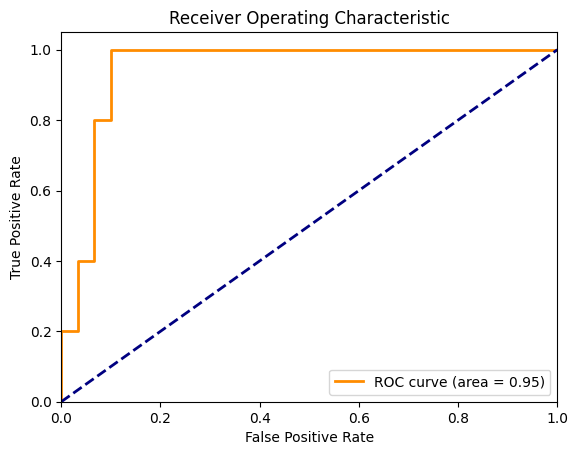

In [32]:
# Visualize ROC Curve
def visualize_roc_curve_lstm(model, X_test_lstm_reshaped, y_test_lstm):
  y_pred_lstm = model.predict(X_test_lstm_reshaped)
  fpr, tpr, thresholds = roc_curve(y_test_lstm, y_pred_lstm)
  roc_auc = auc(fpr, tpr)
  plt.figure()
  plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
  plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
  plt.xlim([0.0, 1.0])
  plt.ylim([0.0, 1.05])
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.title('Receiver Operating Characteristic')
  plt.legend(loc="lower right")
  plt.show()
  return fpr, tpr, thresholds

fpr, tpr, thresholds = visualize_roc_curve_lstm(model, X_test_lstm_reshaped, y_test_lstm)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


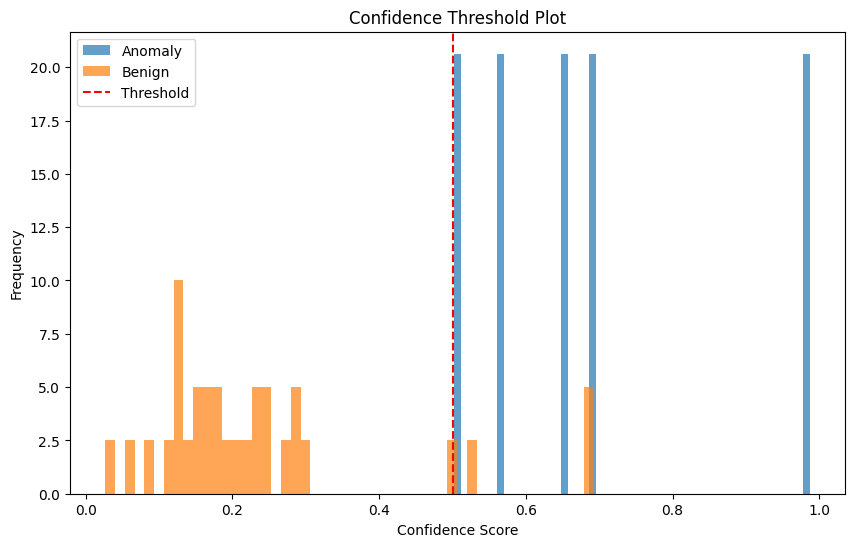

In [33]:
# Confidence Threshold plot
def confidence_threshold_plot(model, X_test_lstm_reshaped, y_test_lstm):
  y_pred_lstm = model.predict(X_test_lstm_reshaped)
  y_pred_lstm_binary = (y_pred_lstm > 0.50)
  plt.figure(figsize=(10, 6))
  plt.hist(y_pred_lstm[y_test_lstm == 1], bins=50, alpha=0.7, label='Anomaly', density=True)
  plt.hist(y_pred_lstm[y_test_lstm == 0], bins=50, alpha=0.7, label='Benign', density=True)
  plt.axvline(x=0.50, color='red', linestyle='--', label='Threshold')
  plt.title("Confidence Threshold Plot")
  plt.xlabel("Confidence Score")
  plt.ylabel("Frequency")
  plt.legend()
  plt.show()

confidence_threshold_plot(model, X_test_lstm_reshaped, y_test_lstm)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


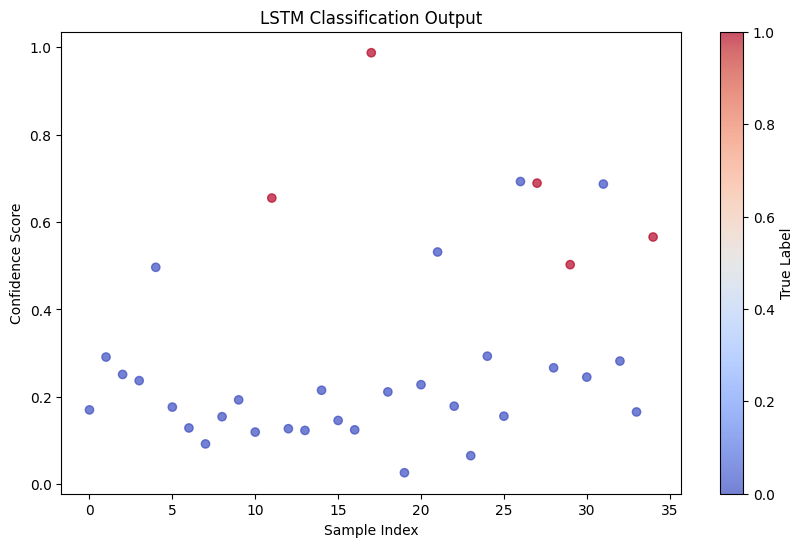

In [34]:
# LSTM classification output plot
def lstm_classification_output_plot(model, X_test_lstm_reshaped, y_test_lstm):
  y_pred_lstm = model.predict(X_test_lstm_reshaped)
  plt.figure(figsize=(10, 6))
  plt.scatter(range(len(y_test_lstm)), y_pred_lstm, c=y_test_lstm, cmap='coolwarm', alpha=0.7)
  plt.title("LSTM Classification Output")
  plt.xlabel("Sample Index")
  plt.ylabel("Confidence Score")
  plt.colorbar(label="True Label")
  plt.show()
  return y_pred_lstm

y_pred_lstm = lstm_classification_output_plot(model, X_test_lstm_reshaped, y_test_lstm)

In [35]:
# Per-enterprise performance breakdown
def enterprise_performance_breakdown_lstm(model, X_test_lstm_reshaped, y_test_lstm, full_df):
  y_pred_lstm = model.predict(X_test_lstm_reshaped)
  y_pred_lstm_binary = (y_pred_lstm > 0.5).astype(int)
  df_test_subset = full_df.loc[y_test_lstm.index].copy()
  df_test_subset['predicted_label'] = y_pred_lstm_binary
  df_test_subset['is_anomalous_session'] = y_test_lstm
  # Explicitly set categories [0, 1] before renaming
  df_test_subset['predicted_label'] = pd.Categorical(df_test_subset['predicted_label'], categories=[0, 1]).rename_categories(['Normal', 'Anomaly'])
  df_test_subset['is_anomalous_session'] = pd.Categorical(df_test_subset['is_anomalous_session'], categories=[0, 1]).rename_categories(['Normal', 'Anomaly'])
  df_test_subset['enterprise_id'] = df_test_subset['enterprise_id'].astype(str)
  df_test_subset['enterprise_id'] = pd.Categorical(df_test_subset['enterprise_id'])
  df_test_subset['enterprise_id'] = df_test_subset['enterprise_id'].cat.rename_categories(df_test_subset['enterprise_id'].unique())
  df_enterprise_performance = df_test_subset.groupby(['enterprise_id', 'predicted_label', 'is_anomalous_session'], observed=True).size().reset_index(name='count')
  return df_enterprise_performance

df_enterprise_performance = enterprise_performance_breakdown_lstm(model, X_test_lstm_reshaped, y_test_lstm, df_session)
df_enterprise_performance = df_enterprise_performance.sort_values(by='enterprise_id')
fig_ent_svm = px.bar(df_enterprise_performance, x='enterprise_id', y='count', color='is_anomalous_session', barmode='group', title='Enterprise Performance Breakdown')
fig_ent_svm.update_layout(xaxis_title='Enterprise ID', yaxis_title='Count')
fig_ent_svm.update_xaxes(type='category', categoryorder='array', categoryarray=df_enterprise_performance['enterprise_id'].unique())
fig_ent_svm.show()

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


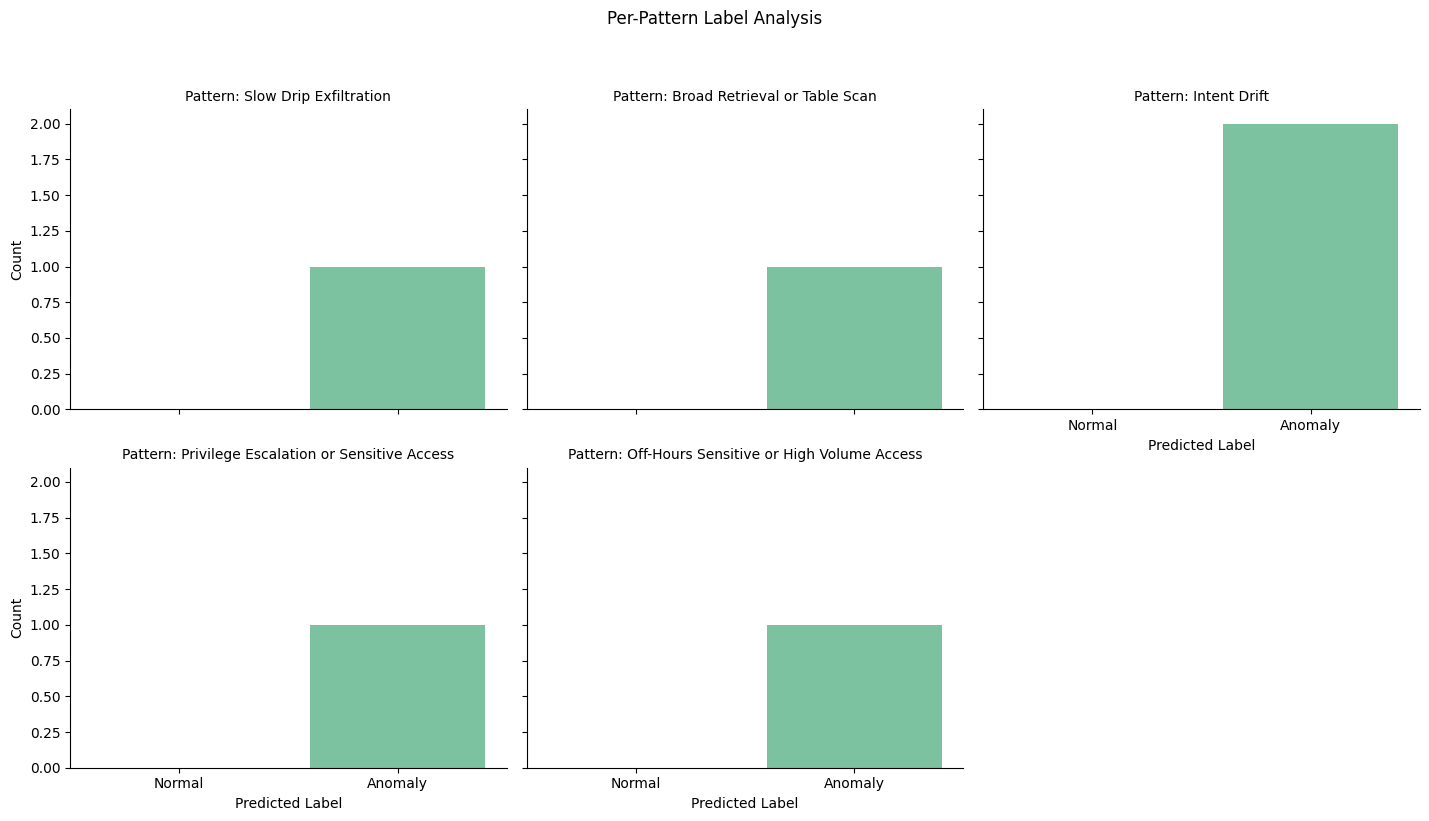

In [36]:
# Per-pattern label analysis plot
labels = ['slow_drip_exfiltration', 'broad_retrieval_or_table_scan', 'intent_drift', 'privilege_escalation_or_sensitive_access_violation', 'high_entropy_exploration', 'off_hours_sensitive_or_high_volume_access']
def per_pattern_label_analysis_lstm(model, X_test_lstm_reshaped, y_test_lstm, labels):
  df_labels_list = []
  df_test_subset = df_session.loc[y_test_lstm.index].copy()
  y_pred_lstm = model.predict(X_test_lstm_reshaped)
  y_pred_lstm_binary = (y_pred_lstm > 0.5).astype(int)
  df_test_subset['predicted_label'] = y_pred_lstm_binary
  df_test_subset['is_anomalous_session'] = y_test_lstm
  df_test_subset['predicted_label'] = pd.Categorical(df_test_subset['predicted_label'], categories=[0, 1]).rename_categories(['Normal', 'Anomaly'])
  df_test_subset['is_anomalous_session'] = pd.Categorical(df_test_subset['is_anomalous_session'], categories=[0, 1]).rename_categories(['Normal', 'Anomaly'])
  for label in labels:
    df_label = df_test_subset[df_test_subset[label] == 1].copy()
    df_label['Pattern'] = label
    df_labels_list.append(df_label)
  return pd.concat(df_labels_list)

combined_df_labels = per_pattern_label_analysis_lstm(model, X_test_lstm_reshaped, y_test_lstm, labels)
pattern_names = {
    'slow_drip_exfiltration': 'Slow Drip Exfiltration',
    'broad_retrieval_or_table_scan': 'Broad Retrieval or Table Scan',
    'intent_drift': 'Intent Drift',
    'privilege_escalation_or_sensitive_access_violation': 'Privilege Escalation or Sensitive Access',
    'high_entropy_exploration': 'High Entropy Exploration',
    'off_hours_sensitive_or_high_volume_access': 'Off-Hours Sensitive or High Volume Access'
}
combined_df_labels['Pattern'] = combined_df_labels['Pattern'].map(pattern_names)
g = sns.catplot(
    data=combined_df_labels,
    x='predicted_label',
    hue='is_anomalous_session',
    col='Pattern',
    kind='count',
    col_wrap=3,
    height=4,
    aspect=1.2,
    alpha=0.7,
    palette='viridis'
)
g.set_axis_labels("Predicted Label", "Count")
g.set_titles("Pattern: {col_name}")
plt.suptitle("Per-Pattern Label Analysis", y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

# Analysis between Baseline and Sequential Modeling

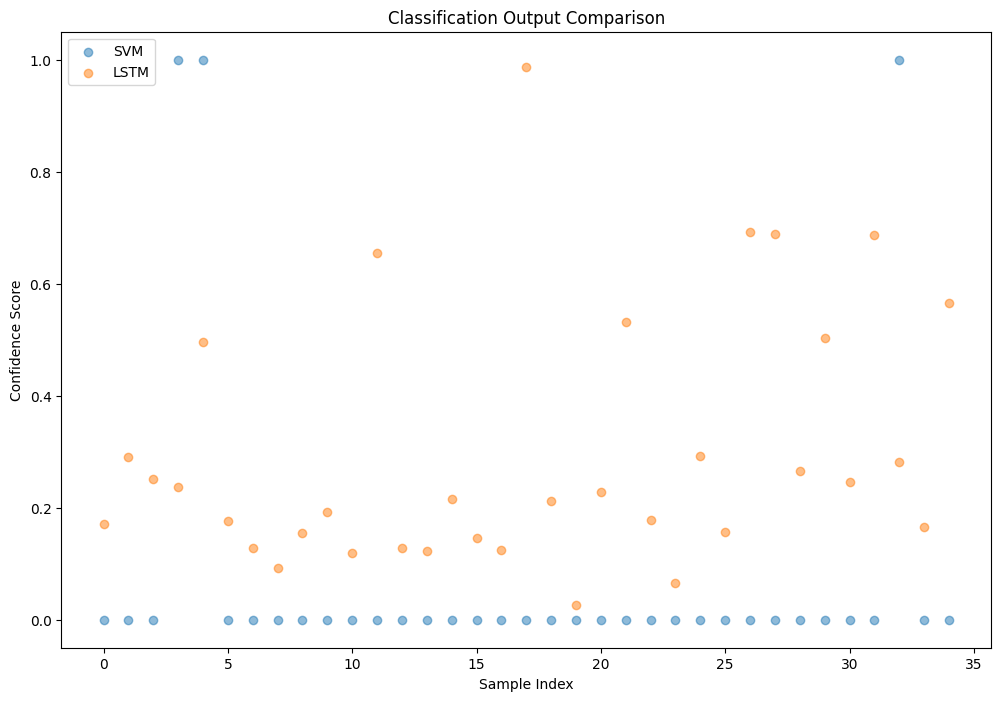

In [37]:
# Classification output per session
def compare_classification_output(svm_classifier, y_pred_lstm, y_test_lstm):
  y_pred_svm = svm_classifier.predict(X_test)
  plt.figure(figsize=(12, 8))
  plt.scatter(range(len(y_test_lstm)), y_pred_svm, label='SVM', alpha=0.5)
  plt.scatter(range(len(y_test_lstm)), y_pred_lstm, label='LSTM', alpha=0.5)
  plt.title("Classification Output Comparison")
  plt.xlabel("Sample Index")
  plt.ylabel("Confidence Score")
  plt.legend()
  plt.show()

compare_classification_output(svc, y_pred_lstm, y_test_lstm)

## Classification Output Comparison

Comparing SVM and LSTM's classification output shows us that SVM makes a clear cut decision of either normal or anomalous, which can be seen with the plots either being 0 or 1. On the other hand, LSTM sets every single prediction around the 0.5 range. This means that LSTM is less sure about which sessions are anomalous as seen by the plots being clustered around 0.5.

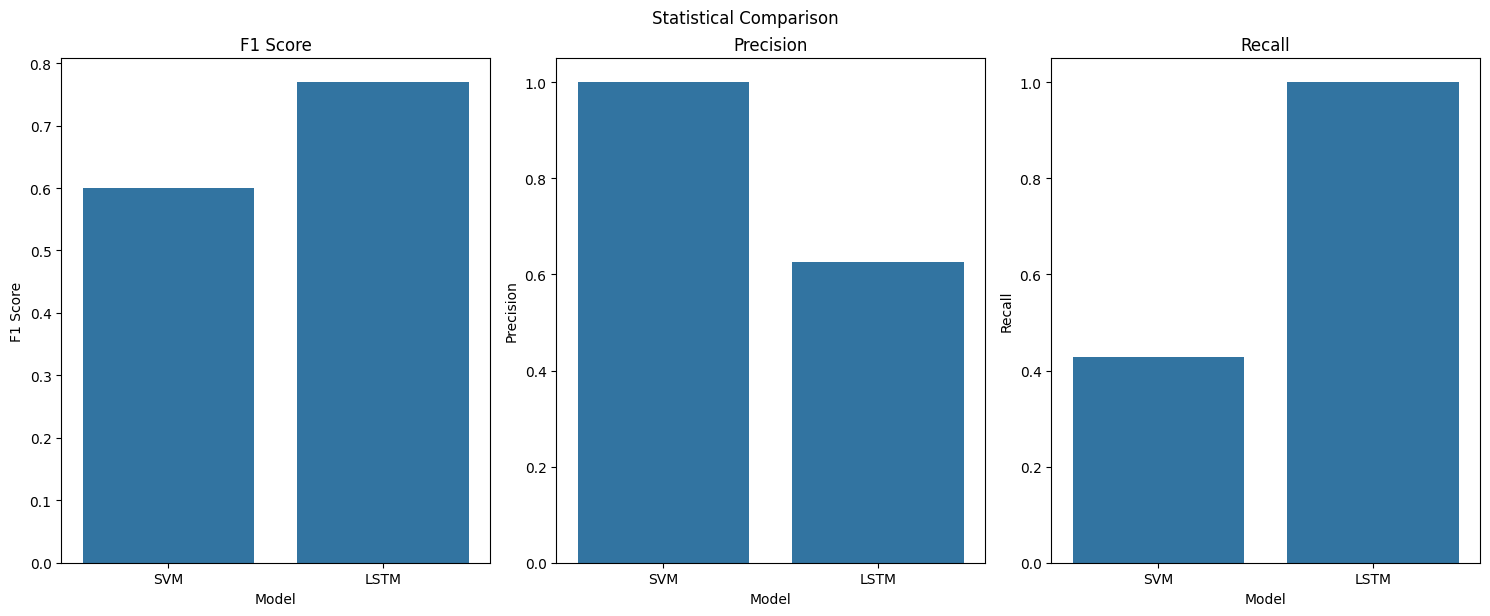

In [38]:
from sklearn.metrics import f1_score, precision_score, recall_score
def statistical_comparison_plot(svm_classifier, y_pred_lstm, y_test_lstm):
  y_pred_svm = svm_classifier.predict(X_test)

  # Convert LSTM probabilities to binary predictions
  y_pred_lstm_binary = (y_pred_lstm > 0.5).astype(int)

  f1_svm = f1_score(y_test, y_pred_svm)
  precision_svm = precision_score(y_test, y_pred_svm)
  recall_svm = recall_score(y_test, y_pred_svm)
  f1_lstm = f1_score(y_test_lstm, y_pred_lstm_binary)
  precision_lstm = precision_score(y_test_lstm, y_pred_lstm_binary)
  recall_lstm = recall_score(y_test_lstm, y_pred_lstm_binary)
  data = {
      'Model': ['SVM', 'LSTM'],
      'F1 Score': [f1_svm, f1_lstm],
      'Precision': [precision_svm, precision_lstm],
      'Recall': [recall_svm, recall_lstm]
  }
  df_comparison = pd.DataFrame(data)
  plt.figure(figsize=(15, 6)) # Increased figure size for 3 plots
  plt.subplot(1, 3, 1) # Changed to 1 row, 3 columns, 1st plot
  sns.barplot(x='Model', y='F1 Score', data=df_comparison)
  plt.title("F1 Score")
  plt.subplot(1, 3, 2) # Changed to 1 row, 3 columns, 2nd plot
  sns.barplot(x='Model', y='Precision', data=df_comparison)
  plt.title("Precision")
  plt.subplot(1, 3, 3) # Changed to 1 row, 3 columns, 3rd plot
  sns.barplot(x='Model', y='Recall', data=df_comparison)
  plt.title("Recall")
  plt.tight_layout()
  plt.suptitle("Statistical Comparison", y=1.02) # Use suptitle for overall title
  plt.show()

statistical_comparison_plot(svc, y_pred_lstm, y_test_lstm)

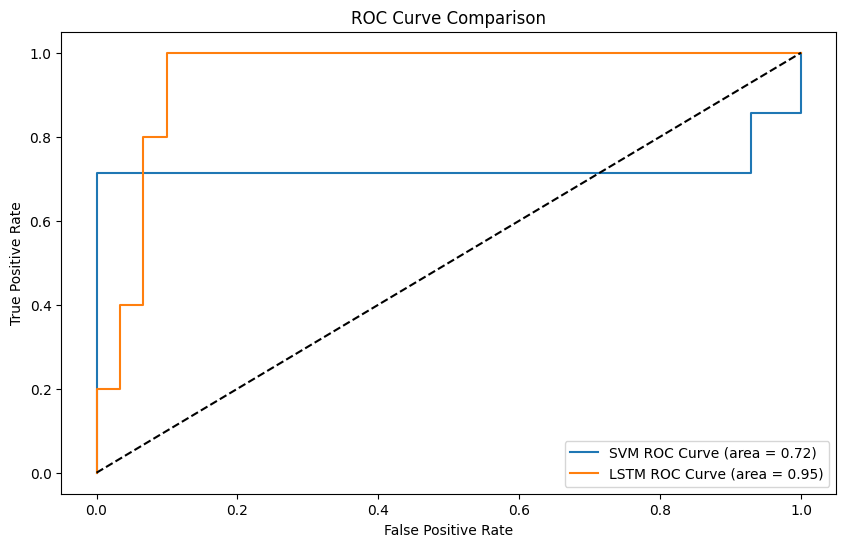

In [39]:
# ROC curve comparison
def roc_curve_comparison(svc, y_pred_lstm, y_test, y_test_lstm):
  fpr_svm, tpr_svm, thresholds_svm = roc_curve(y_test, svc.decision_function(X_test))
  fpr_lstm, tpr_lstm, thresholds_lstm = roc_curve(y_test_lstm, y_pred_lstm)
  roc_auc_svm = auc(fpr_svm, tpr_svm)
  roc_auc_lstm = auc(fpr_lstm, tpr_lstm)
  plt.figure(figsize=(10, 6))
  plt.plot(fpr_svm, tpr_svm, label=f'SVM ROC Curve (area = {roc_auc_svm:.2f})')
  plt.plot(fpr_lstm, tpr_lstm, label=f'LSTM ROC Curve (area = {roc_auc_lstm:.2f})')
  plt.plot([0, 1], [0, 1], 'k--')
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.title('ROC Curve Comparison')
  plt.legend()
  plt.show()

roc_curve_comparison(svc, y_pred_lstm, y_test, y_test_lstm)

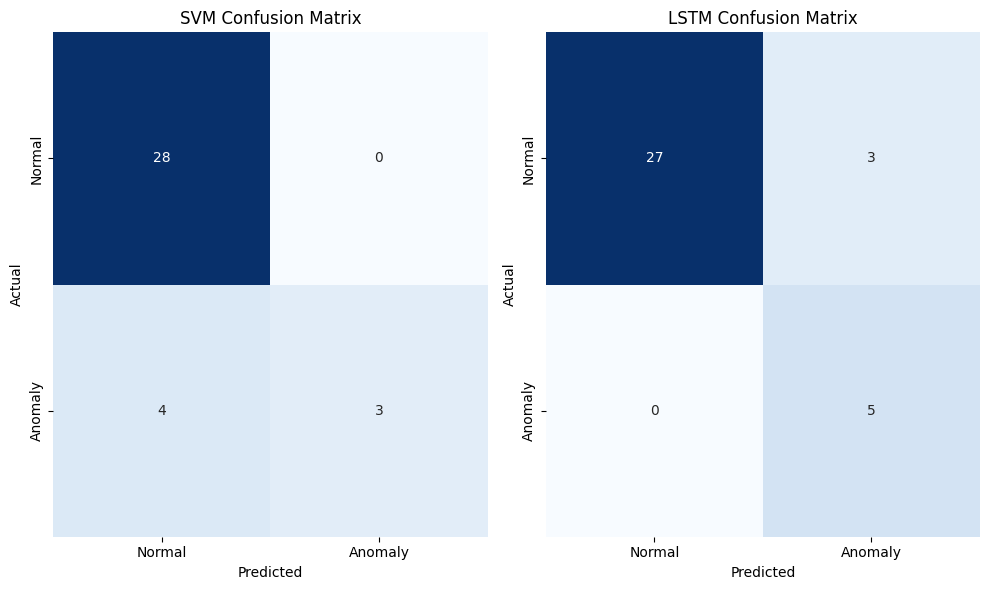

In [40]:
# Confusion Matrix Comparison
def confusion_matrix_comparison(svc, y_pred_lstm, y_test, y_test_lstm):
  cm_svm = confusion_matrix(y_test, svc.predict(X_test))
  cm_lstm = confusion_matrix(y_test_lstm, (y_pred_lstm > 0.5).astype(int))
  plt.figure(figsize=(10, 6))
  plt.subplot(1, 2, 1)
  sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=['Normal', 'Anomaly'], yticklabels=['Normal', 'Anomaly'])
  plt.title('SVM Confusion Matrix')
  plt.xlabel('Predicted')
  plt.ylabel('Actual')
  plt.subplot(1, 2, 2)
  sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=['Normal', 'Anomaly'], yticklabels=['Normal', 'Anomaly'])
  plt.title('LSTM Confusion Matrix')
  plt.xlabel('Predicted')
  plt.ylabel('Actual')
  plt.tight_layout()
  plt.show()

confusion_matrix_comparison(svc, y_pred_lstm, y_test, y_test_lstm)

## Statistical Comparison

From the statistical comparison between SVM and LSTM, we can conclude that our LSTM model performs better than SVM. We can see this from the recall, ROC curve, and confusion matrix being higher than SVM. The precision is the only stat where SVM is higher than LSTM. This concludes that LSTM predicts less false negatives than SVM. The F1 scores of both models are near the same.

We believe that false negatives are more important than false positives. This is because a false negative flag could have potentially destructive consequences for the server, while false positive flags deny benign activity.

Looking at the confusion matrix, SVM seems to falsely flag 4 anomalous sessions as normal, while LSTM falsely flags 7 benign sessions as anomalous. In the case of defending against AI agent queries, we would prefer false positives because false negatives could have destructive consequences.

In [41]:
# Enterprise comparison
def enterprise_performance_comparison():
  df_enterprise_performance_svm = enterprise_performance_breakdown(svc, X_test, y_test, df_session)
  df_enterprise_performance_lstm = enterprise_performance_breakdown_lstm(model, X_test_lstm_reshaped, y_test_lstm, df_session)
  df_enterprise_performance_svm = df_enterprise_performance_svm.sort_values(by='enterprise_id')
  df_enterprise_performance_lstm = df_enterprise_performance_lstm.sort_values(by='enterprise_id')
  df_enterprise_performance_svm['model'] = 'SVM'
  df_enterprise_performance_lstm['model'] = 'LSTM'
  # Correctly concatenate both SVM and LSTM dataframes
  df_enterprise_performance_combined = pd.concat([df_enterprise_performance_svm, df_enterprise_performance_lstm])

  fig_ent = px.bar(df_enterprise_performance_combined,
                   x='enterprise_id',
                   y='count',
                   color='is_anomalous_session',
                   barmode='group',
                   facet_row='model', # Split by model
                   title='Enterprise Performance Breakdown by Model',
                   height=700) # Increased height for faceted plots
  fig_ent.update_layout(xaxis_title='Enterprise ID', yaxis_title='Count')
  fig_ent.update_xaxes(type='category')
  fig_ent.show()
  return df_enterprise_performance_combined

df_enterprise_performance_combined = enterprise_performance_comparison()

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


## Enterprise Performance Breakdown

From the enterprise performance breakdown we can see that Apex Gamma has detected the most anomalies with 6. Meanwhile, Corp Alpha has detected the least anomalies with 2. Nexus Beta sits in the middle of the other enterprises with 4 anomalies. With the split models, the SVM and LSTM flag the same amount of anomalies with 7.

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


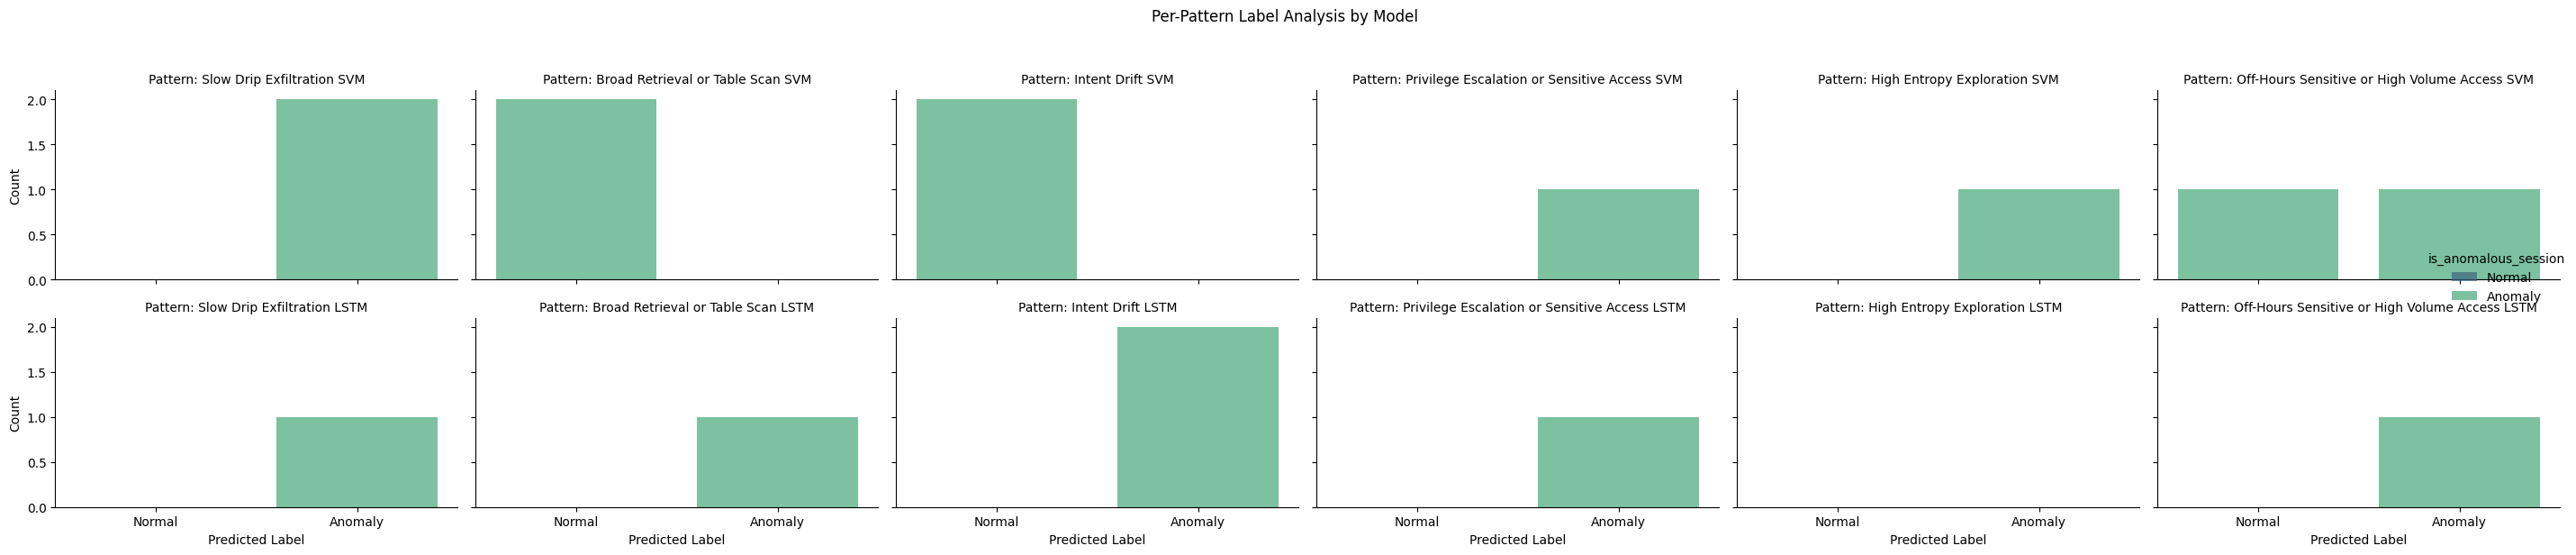

In [42]:
# Per-pattern combined analysis plot
def per_pattern_combined_label_analysis():
  # Get SVM results (Pattern column contains unmapped names)
  svm_df = per_pattern_label_analysis(svc, X_test, y_test, labels)
  # Get LSTM results (Pattern column contains unmapped names)
  lstm_df = per_pattern_label_analysis_lstm(model, X_test_lstm_reshaped, y_test_lstm, labels)

  # Add a 'model' column to distinguish between SVM and LSTM results
  svm_df['model'] = 'SVM'
  lstm_df['model'] = 'LSTM'

  # Concatenate the results
  per_pattern_label_analysis_combined = pd.concat([svm_df, lstm_df])
  return per_pattern_label_analysis_combined

per_pattern_label_analysis_combined = per_pattern_combined_label_analysis()

pattern_names = {
    'slow_drip_exfiltration': 'Slow Drip Exfiltration',
    'broad_retrieval_or_table_scan': 'Broad Retrieval or Table Scan',
    'intent_drift': 'Intent Drift',
    'privilege_escalation_or_sensitive_access_violation': 'Privilege Escalation or Sensitive Access',
    'high_entropy_exploration': 'High Entropy Exploration',
    'off_hours_sensitive_or_high_volume_access': 'Off-Hours Sensitive or High Volume Access'
}
# Map pattern labels to more readable names for the plot, only once
per_pattern_label_analysis_combined['Pattern'] = per_pattern_label_analysis_combined['Pattern'].map(pattern_names)

g = sns.catplot(
    data=per_pattern_label_analysis_combined,
    x='predicted_label',
    hue='is_anomalous_session',
    col='Pattern',
    row='model', # Added row for model to split by model
    kind='count',
    # col_wrap=3, # Removed col_wrap as row is used for faceting
    height=3, # Adjusted height for more subplots
    aspect=1.5, # Adjusted aspect for more subplots
    alpha=0.7,
    palette='viridis'
)
g.set_axis_labels("Predicted Label", "Count")
g.set_titles("Pattern: {col_name} {row_name}")
plt.suptitle("Per-Pattern Label Analysis by Model", y=1.02) # Adjusted suptitle
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

## Per-Pattern Analysis

From our pattern analysis list, the hardest pattern to detect seems to be Broad Rerieval or Table Scan. The SVM wrongly flags both sessions as benign unlike the LSTM correctly flagging an anomaly as suspicious activity. The easiest anomaly family to predict seems to be slow drop exfiltration as all three listed anomalies in the test set for both SVM and LSTM were flagged an anomalous.

In [43]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score

# Permutation importance for PCA-based SVM
def calculate_pca_permutation_importance(svc, pca_transformer, X_test_full_features, y_test, feature_names, n_repeats=50):
  """
  Calculates permutation importance for an SVM model that uses PCA for dimension reduction.

  Args:
    svc: The trained SVM model (trained on PCA components).
    pca_transformer: The fitted PCA object used for dimension reduction.
    X_test_full_features: The scaled 19-dimensional test data (before PCA).
    y_test: The true labels for the test set.
    feature_names: A list of the original feature names.
    n_repeats: Number of times to shuffle each feature and average the accuracy drop.

  Returns:
    A pandas Series containing the permutation importances (average accuracy drop) for each feature.
  """

  # First, transform the original X_test_full_features to PCA components
  X_test_pca = pca_transformer.transform(X_test_full_features)
  # Evaluate baseline accuracy on the unshuffled PCA-transformed data
  baseline_accuracy = svc.score(X_test_pca, y_test)
  print(f"Baseline Accuracy (SVM on PCA): {baseline_accuracy:.4f}")

  importances = {}
  num_original_features = X_test_full_features.shape[1]

  for i, feature_name in enumerate(feature_names):
    feature_accuracy_drops = []
    for _ in range(n_repeats):
      # Create a copy of the full feature test data to avoid modifying the original
      shuffled_X_full_features = X_test_full_features.copy()

      # Shuffle the current feature's values across all samples in the original feature space
      shuffled_X_full_features.iloc[:, i] = np.random.permutation(shuffled_X_full_features.iloc[:, i].values)

      # Transform the shuffled full features back to PCA components
      shuffled_X_pca = pca_transformer.transform(shuffled_X_full_features)

      # Evaluate the SVM model with the shuffled feature (in PCA space)
      shuffled_accuracy = svc.score(shuffled_X_pca, y_test)

      # The importance is the drop in accuracy due to shuffling this feature
      feature_accuracy_drops.append(baseline_accuracy - shuffled_accuracy)

    # Average the accuracy drops for this feature
    importances[feature_name] = np.mean(feature_accuracy_drops)
    print(f"  Permuting '{feature_name}' ({n_repeats} repeats): Average Accuracy drop = {importances[feature_name]:.4f}")

  return pd.Series(importances).sort_values(ascending=False)

# Calculate SVM permutation importance using the defined function
# 'X_test_full_features' is the 19-dimensional scaled data for the test set, used to fit PCA.
# 'columns' contains the names of the 19 original features.
svm_permutation_importances = calculate_pca_permutation_importance(svc, pca_transformer, X_test_full_features, y_test, columns, n_repeats=50)

Baseline Accuracy (SVM on PCA): 0.8857
  Permuting 'intent_drift_score' (50 repeats): Average Accuracy drop = -0.0011
  Permuting 'unique_tables_accessed' (50 repeats): Average Accuracy drop = 0.0137
  Permuting 'entropy_table_access_sequence' (50 repeats): Average Accuracy drop = -0.0011
  Permuting 'duration_seconds' (50 repeats): Average Accuracy drop = -0.0046
  Permuting 'sensitive_table_access_count' (50 repeats): Average Accuracy drop = 0.0000
  Permuting 'row_estimate' (50 repeats): Average Accuracy drop = 0.0000
  Permuting 'num_events' (50 repeats): Average Accuracy drop = 0.0046
  Permuting 'cross_table_join_count' (50 repeats): Average Accuracy drop = 0.0000
  Permuting 'time_delta_mean' (50 repeats): Average Accuracy drop = 0.0000
  Permuting 'confidence_mean' (50 repeats): Average Accuracy drop = -0.0006
  Permuting 'user_role' (50 repeats): Average Accuracy drop = 0.0000
  Permuting 'declared_intent' (50 repeats): Average Accuracy drop = 0.0000
  Permuting 'select_count'

In [44]:
from sklearn.metrics import accuracy_score

# Understanding Feature Importance for LSTMs:
# Unlike PCA for SVM, LSTMs do not have a direct 'inverse transform' mechanism
# to reconstruct original features from their internal representations.
# To assess the importance of original features to an LSTM model's predictions,
# permutation importance is a widely used and interpretable model-agnostic technique.

def calculate_lstm_permutation_importance(model, X_test_reshaped, y_test, feature_names):
  """
  Calculates permutation importance for a Keras LSTM model.

  Args:
    model: The trained Keras LSTM model.
    X_test_reshaped: The reshaped test features (samples, timesteps, features).
                     In this case, (samples, num_features, 1).
    y_test: The true labels for the test set.
    feature_names: A list of the original feature names corresponding to the timesteps.

  Returns:
    A pandas Series containing the permutation importances (accuracy drop) for each feature.
  """
  # Evaluate baseline accuracy on the unshuffled data
  _, baseline_accuracy = model.evaluate(X_test_reshaped, y_test, verbose=0)
  print(f"Baseline Accuracy: {baseline_accuracy:.4f}")

  importances = {}
  num_features = X_test_reshaped.shape[1]

  for i, feature_name in enumerate(feature_names):
    # Create a copy of the reshaped test data to avoid modifying the original
    shuffled_X = X_test_reshaped.copy()

    # Shuffle the current feature's values across all samples
    # The feature is at index 'i' in the second dimension (timesteps) and at index 0 in the third dimension (single feature per timestep)
    np.random.shuffle(shuffled_X[:, i, 0])

    # Evaluate the model with the shuffled feature
    _, shuffled_accuracy = model.evaluate(shuffled_X, y_test, verbose=0)

    # The importance is the drop in accuracy due to shuffling this feature
    importances[feature_name] = baseline_accuracy - shuffled_accuracy
    print(f"  Permuting '{feature_name}': Accuracy drop = {baseline_accuracy - shuffled_accuracy:.4f}")

  return pd.Series(importances).sort_values(ascending=False)

lstm_importances = calculate_lstm_permutation_importance(model, X_test_lstm_reshaped, y_test_lstm, lstm_feature_cols)

Baseline Accuracy: 0.9143
  Permuting 'intent_drift_score': Accuracy drop = 0.0571
  Permuting 'unique_tables_accessed': Accuracy drop = -0.0571
  Permuting 'entropy_table_access_sequence': Accuracy drop = 0.0571
  Permuting 'duration_seconds': Accuracy drop = 0.0000
  Permuting 'sensitive_table_access_count': Accuracy drop = 0.0571
  Permuting 'row_estimate': Accuracy drop = 0.0286


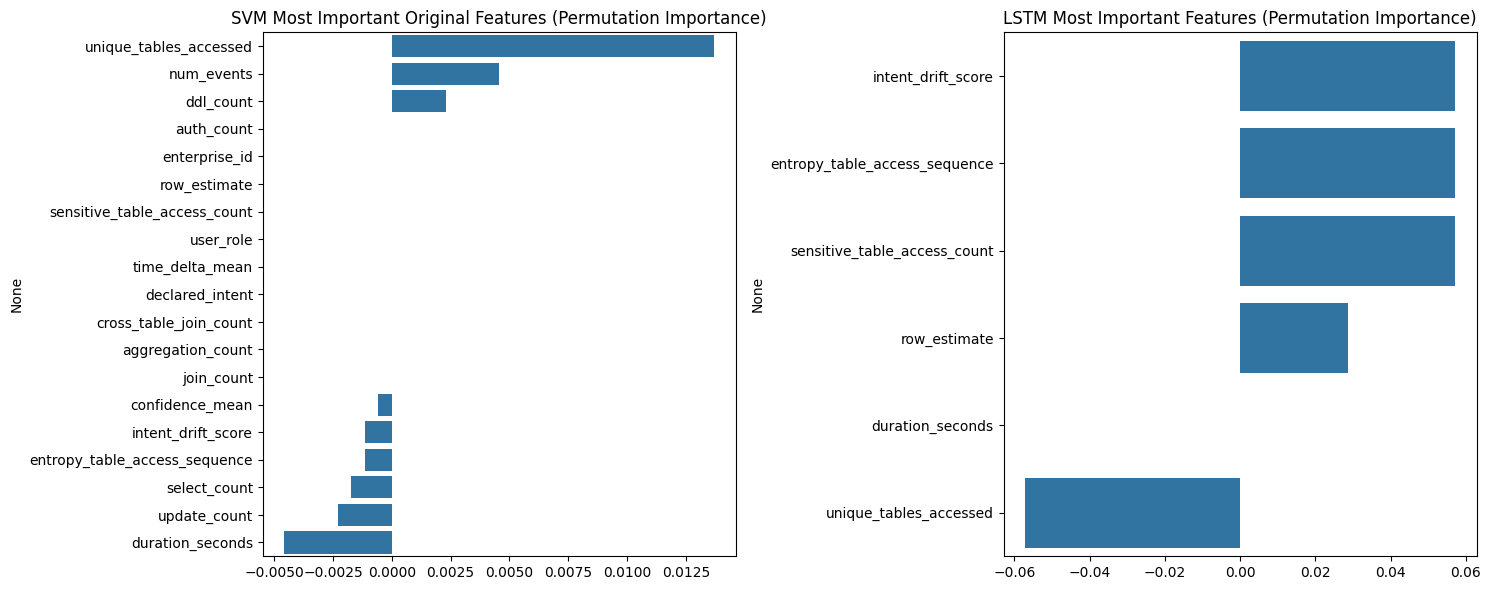

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Compare Most Important Features
def compare_most_important_features(svm_importances, lstm_importances):
  plt.figure(figsize=(15, 6))
  plt.subplot(1, 2, 1)
  sns.barplot(x=svm_importances.values, y=svm_importances.index)
  plt.title("SVM Most Important Original Features (Permutation Importance)")
  plt.subplot(1, 2, 2)
  sns.barplot(x=lstm_importances.values, y=lstm_importances.index)
  plt.title("LSTM Most Important Features (Permutation Importance)")
  plt.tight_layout()
  plt.show()
  return svm_importances, lstm_importances

# Call the function with the permutation importances for SVM and LSTM
svm_importances_for_plotting, lstm_importances_for_plotting = compare_most_important_features(svm_permutation_importances, lstm_importances)

## Feature Importance
For SVM, the most important 3 features are unique_tables_accessed, num_events, and ddl_count. This could explain the reason why the model struggled detecting broad retrievals or table scans and intent drift anomalies. The most important features with LSTM were intent drift score, entropy of table access sequence, and sensitive table access count. Row estimate also weighed positively on LSTM's analysis. This could explain the perfect detection of anomalies with LSTM as the model identifies features indictive of suspicious behaviour.

# System in Practice
If I were to deploy the LSTM model in practice, I would remove duration_seconds as a feature used by the LSTM as the feature seems to have not made an importance in training. The LSTM model would be deployed on the system using the host server in the company who requests the model be deployed. This way, the model would work as a Network Intrusion Detection System (NIDS). The NIDS would be monitored by the system administrator who would have control over what specific sessions will be flagged. Human moderation of the NIDS would be required for edge cases of below 0.6 confidence score.